In [2]:
import subprocess
import sys

packages = ['pandas', 'numpy', 'scikit-learn', 'matplotlib', 'seaborn', 'gradio', 'joblib']

print("📦 Installing required packages...")
for package in packages:
    try:
        __import__(package)
        print(f"   ✓ {package} already installed")
    except ImportError:
        print(f"   ⬇️ Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"   ✓ {package} installed")

print("\n✅ All packages ready!")

📦 Installing required packages...
   ✓ pandas already installed
   ✓ numpy already installed
   ⬇️ Installing scikit-learn...
   ✓ scikit-learn installed
   ✓ matplotlib already installed
   ✓ seaborn already installed
   ✓ gradio already installed
   ✓ joblib already installed

✅ All packages ready!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, recall_score, precision_score, accuracy_score, f1_score, classification_report
import gradio as gr
import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')
print("✅ All libraries imported successfully!")
print(f"   Pandas: {pd.__version__}")
print(f"   Working directory: {os.getcwd()}")


✅ All libraries imported successfully!
   Pandas: 2.2.2
   Working directory: C:\Users\blaizo\Desktop\ML_Gradio_Projects\Medical_Diagnostic


In [69]:
# Column names for the dataset
column_names = [
    'age',        # age in years
    'sex',        # sex (1 = male; 0 = female)
    'cp',         # chest pain type (1-4)
    'trestbps',   # resting blood pressure (mm Hg)
    'chol',       # serum cholesterol (mg/dl)
    'fbs',        # fasting blood sugar > 120 mg/dl (1 = true; 0 = false)
    'restecg',    # resting electrocardiographic results (0-2)
    'thalach',    # maximum heart rate achieved
    'exang',      # exercise induced angina (1 = yes; 0 = no)
    'oldpeak',    # ST depression induced by exercise relative to rest
    'slope',      # the slope of the peak exercise ST segment (1-3)
    'ca',         # number of major vessels (0-3) colored by fluoroscopy
    'thal',       # thalium stress test result (3 = normal; 6 = fixed defect; 7 = reversible defect)
    'target'      # diagnosis of heart disease (0 = no disease, 1 = disease)
]

# Load the dataset from your local path
df = pd.read_csv("heart_disease_uci.csv", names=column_names, na_values='?')
print(f"✅ Dataset loaded successfully!")
print(f"📊 Dataset shape: {df.shape}")
print(f"\n📋 First 5 rows:")
print(df.head())

# Save column names for later use
with open('heart_disease_columns.json', 'w') as f:
    json.dump(column_names, f)

print(f"\n💾 Column names saved locally")


✅ Dataset loaded successfully!
📊 Dataset shape: (921, 14)

📋 First 5 rows:
         age        sex              cp  trestbps  chol    fbs  \
id age   sex    dataset              cp  trestbps  chol    fbs   
1  63   Male  Cleveland  typical angina       145   233   TRUE   
2  67   Male  Cleveland    asymptomatic       160   286  FALSE   
3  67   Male  Cleveland    asymptomatic       120   229  FALSE   
4  37   Male  Cleveland     non-anginal       130   250  FALSE   

               restecg thalach  exang  oldpeak        slope  ca  \
id age         restecg  thalch  exang  oldpeak        slope  ca   
1  63   lv hypertrophy     150  FALSE      2.3  downsloping   0   
2  67   lv hypertrophy     108   TRUE      1.5         flat   3   
3  67   lv hypertrophy     129   TRUE      2.6         flat   2   
4  37           normal     187  FALSE      3.5  downsloping   0   

                     thal target  
id age               thal    num  
1  63        fixed defect      0  
2  67              n

📊 Missing values before cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

✅ Removed 0 rows with missing values
✅ New dataset size: 300

📊 Target variable distribution:
target
0      160
1       56
2       35
3       35
4       13
num      1
Name: count, dtype: int64

💾 Cleaned data saved as: heart_disease_cleaned.csv


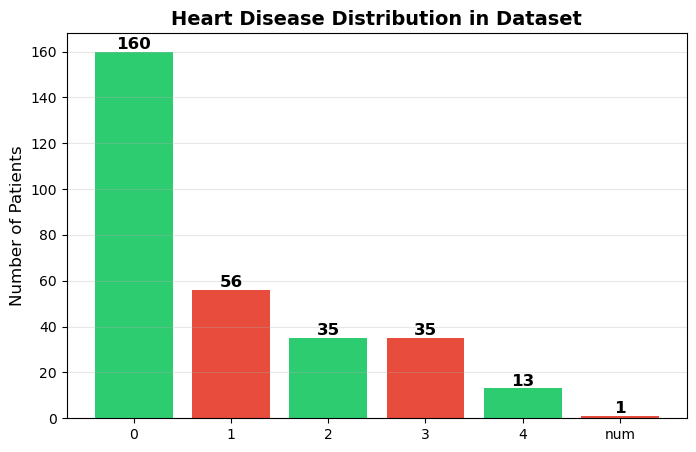

In [20]:
import matplotlib.pyplot as plt

# Check for missing values
print("📊 Missing values before cleaning:")
print(df.isnull().sum())

# Remove rows with missing values
original_size = len(df)
df = df.dropna()
print(f"\n✅ Removed {original_size - len(df)} rows with missing values")
print(f"✅ New dataset size: {len(df)}")

# Check target distribution
print(f"\n📊 Target variable distribution:")
target_counts = df['target'].value_counts()
print(target_counts)

# Save cleaned data
df.to_csv('heart_disease_cleaned.csv', index=False)
print(f"\n💾 Cleaned data saved as: heart_disease_cleaned.csv")

# Visualize
plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c']
labels = target_counts.index.astype(str)  # Convert class labels to strings
bars = plt.bar(labels, target_counts.values, color=colors)
plt.title('Heart Disease Distribution in Dataset', fontsize=14, fontweight='bold')
plt.ylabel('Number of Patients', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.show()

In [45]:
# Split features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

print(f"📊 Features shape: {X.shape}")
print(f"📊 Target shape: {y.shape}")
print(f"\n📋 Features: {list(X.columns)}")

# Check class counts
print("Class distribution in y:")
print(y.value_counts())

# Convert y to numeric, coercing errors to NaN
y_train = pd.to_numeric(y_train, errors='coerce')
y_test = pd.to_numeric(y_test, errors='coerce')

# Drop NaN values in y_train and corresponding X_train rows
train_mask = ~y_train.isna()
X_train = X_train[train_mask]
y_train = y_train[train_mask]

# Drop NaN values in y_test and corresponding X_test rows
test_mask = ~y_test.isna()
X_test = X_test[test_mask]
y_test = y_test[test_mask]

# Drop rows with NaN in target
df = df.dropna(subset=['target'])
X = df.drop('target', axis=1)
y = df['target']
print(y_train.value_counts())
print(y_test.value_counts())

# If there are multiple categorical features, use pd.get_dummies()
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Check class counts for stratify feasibility
if y.value_counts().min() < 2:
    print("Warning: Some classes have less than 2 samples. Stratified splitting is not possible.")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

print(f"\n📊 Data Split:")
print(f"   Training set: {len(X_train)} patients ({len(X_train)/len(df)*100:.0f}%)")
print(f"   Testing set: {len(X_test)} patients ({len(X_test)/len(df)*100:.0f}%)")
# print(f"   Training disease rate: {y_train.mean()*100:.1f}%")
# print(f"   Testing disease rate: {y_test.mean()*100:.1f}%")
# Save splits
# X_train.to_csv('X_train.csv', index=False)
# X_test.to_csv('X_test.csv', index=False)
# y_train.to_csv('y_train.csv', index=False)
# y_test.to_csv('y_test.csv', index=False)
# print(f"\n💾 Data splits saved locally")

📊 Features shape: (300, 13)
📊 Target shape: (300,)

📋 Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Class distribution in y:
target
0      160
1       56
2       35
3       35
4       13
num      1
Name: count, dtype: int64
target
0.0    134
1.0     43
2.0     26
3.0     25
4.0     11
Name: count, dtype: int64
target
0    26
1    13
3    10
2     9
4     2
Name: count, dtype: int64

📊 Data Split:
   Training set: 240 patients (80%)
   Testing set: 60 patients (20%)


In [48]:
# 1. Apply get_dummies to both datasets separately
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# 2. Align columns of X_test to X_train
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# 3. Now proceed with imputation
# Convert boolean columns to integers
X_train = X_train.astype(int)
X_test = X_test.astype(int)

# Now, fit the imputer
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='most_frequent')

# Fit on training data
imputer.fit(X_train)

# Transform datasets
X_train_imputed = pd.DataFrame(imputer.transform(X_train), columns=X_train.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)
# 4. Now train the model
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
print("🔄 Training model on imputed data...")
model.fit(X_train_imputed, y_train)

# 5. Evaluate
print("✅ Model trained successfully!")
print(f"\n📊 Model Parameters:")
print(f"   Algorithm: Logistic Regression")
print(f"   Class weight: balanced (prioritizes catching sick patients)")
print(f"   Training accuracy: {model.score(X_train_imputed, y_train):.2%}")

# Cross-validation
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model, X_train_imputed, y_train, cv=5, scoring='recall')
print(f"\n📊 5-Fold Cross-Validation RECALL Scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"   Fold {i}: {score:.3f}")
print(f"   Average RECALL: {cv_scores.mean():.3f}")

🔄 Training model on imputed data...
✅ Model trained successfully!

📊 Model Parameters:
   Algorithm: Logistic Regression
   Class weight: balanced (prioritizes catching sick patients)
   Training accuracy: 94.58%

📊 5-Fold Cross-Validation RECALL Scores:
   Fold 1: nan
   Fold 2: nan
   Fold 3: nan
   Fold 4: nan
   Fold 5: nan
   Average RECALL: nan


In [54]:
# Make predictions
# Get predicted probabilities
y_proba = model.predict_proba(X_test)[:, 1]
# Set a lower threshold to improve recall
threshold = 0.3
y_pred = (y_proba >= threshold).astype(int)
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("="*60)
print("🔬 HEART DISEASE DIAGNOSIS MODEL - RESULTS")
print("="*60)

print("\n📊 CONFUSION MATRIX:")
print("                     Predicted: No Disease  Predicted: Disease")
print(f"Actual: No Disease         {cm[0,0]}                    {cm[0,1]}")
print(f"Actual: Disease            {cm[1,0]}                    {cm[1,1]}")

# Critical metrics
false_negatives = cm[1,0]  # Sick patients told they're healthy
true_positives = cm[1,1]   # Sick patients correctly identified
total_sick = false_negatives + true_positives

recall = recall_score(y_test, y_pred, average='macro')
precision = precision_score(y_test, y_pred, average='macro')
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')

print(f"\n❌ CRITICAL ERROR: {false_negatives} sick patient\\s were told they are HEALTHY!")
print(f"   This is the FALSE NEGATIVE count - MOST DANGEROUS in medicine")
print(f"   Out of {total_sick} sick patients, we missed {false_negatives}")

print(f"\n📊 MODEL PERFORMANCE METRICS:")
print(f"   🏥 RECALL (Sensitivity): {recall:.2%} ← MOST IMPORTANT")
print(f"      → Caught {true_positives} out of {total_sick} sick patients")
print(f"   📍 PRECISION: {precision:.2%}")
print(f"   🎯 ACCURACY: {accuracy:.2%} (don't rely on this)")
print(f"   ⚖️ F1-SCORE: {f1:.2%}")

print(f"\n💡 INTERPRETATION:")
if recall > 0.85:
    print(f"   ✅ EXCELLENT: Model catches {recall:.0%} of sick patients")
elif recall > 0.70:
    print(f"   👍 GOOD: Model catches {recall:.0%} of sick patients")
else:
    print(f"   ⚠️ NEEDS IMPROVEMENT: Model only catches {recall:.0%} of sick patients")

# Save evaluation results
results = {
    'recall': float(recall),
    'precision': float(precision),
    'accuracy': float(accuracy),
    'f1_score': float(f1),
    'false_negatives': int(false_negatives),
    'true_positives': int(true_positives),
    'confusion_matrix': cm.tolist()
}

# with open('model_results.json', 'w') as f:
#     json.dump(results, f, indent=2)
# print(f"\n💾 Results saved to: model_results.json")

🔬 HEART DISEASE DIAGNOSIS MODEL - RESULTS

📊 CONFUSION MATRIX:
                     Predicted: No Disease  Predicted: Disease
Actual: No Disease         17                    5
Actual: Disease            4                    2

❌ CRITICAL ERROR: 4 sick patient\s were told they are HEALTHY!
   This is the FALSE NEGATIVE count - MOST DANGEROUS in medicine
   Out of 6 sick patients, we missed 4

📊 MODEL PERFORMANCE METRICS:
   🏥 RECALL (Sensitivity): 26.60% ← MOST IMPORTANT
      → Caught 2 out of 6 sick patients
   📍 PRECISION: 28.33%
   🎯 ACCURACY: 40.00% (don't rely on this)
   ⚖️ F1-SCORE: 26.76%

💡 INTERPRETATION:
   ⚠️ NEEDS IMPROVEMENT: Model only catches 27% of sick patients


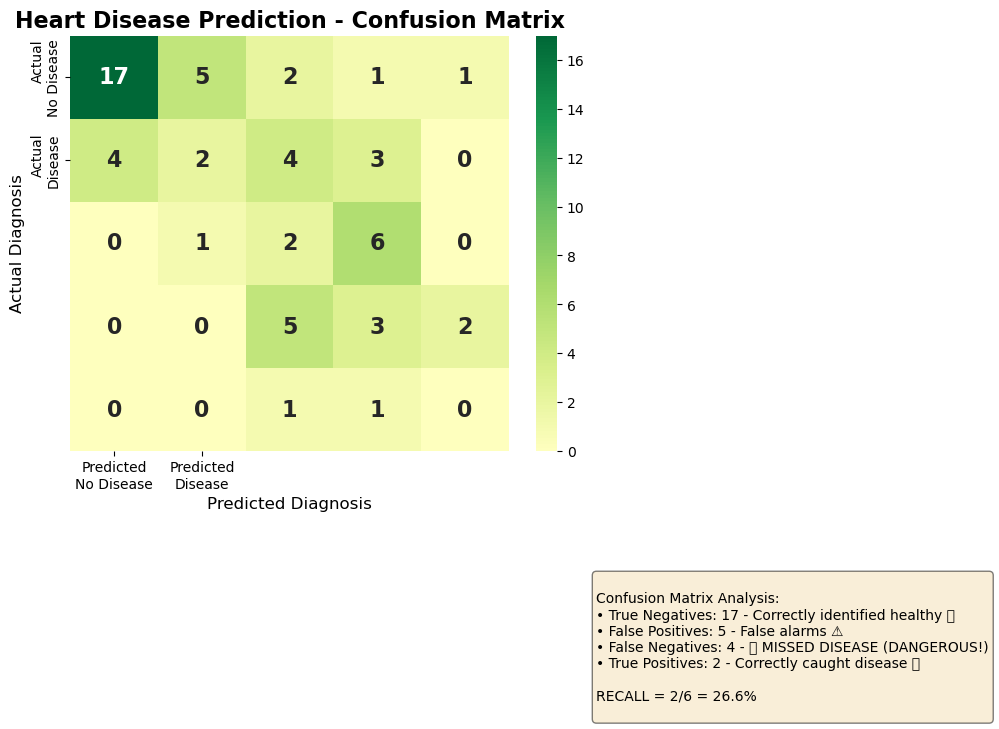

📊 Confusion matrix saved as: confusion_matrix.png


In [53]:
fig, ax = plt.subplots(figsize=(10, 8))

# Create heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', center=0,
            xticklabels=['Predicted\nNo Disease', 'Predicted\nDisease'],
            yticklabels=['Actual\nNo Disease', 'Actual\nDisease'],
            ax=ax, annot_kws={'size': 16, 'weight': 'bold'})

plt.title('Heart Disease Prediction - Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual Diagnosis', fontsize=12)
plt.xlabel('Predicted Diagnosis', fontsize=12)

# Add explanation
explanation = f"""
Confusion Matrix Analysis:
• True Negatives: {cm[0,0]} - Correctly identified healthy ✅
• False Positives: {cm[0,1]} - False alarms ⚠️
• False Negatives: {cm[1,0]} - ❌ MISSED DISEASE (DANGEROUS!)
• True Positives: {cm[1,1]} - Correctly caught disease ✅

RECALL = {cm[1,1]}/{total_sick} = {recall:.1%}
"""

plt.text(1.2, -0.3, explanation, transform=ax.transAxes, 
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("📊 Confusion matrix saved as: confusion_matrix.png")

In [59]:
def predict_heart_disease(age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal):
    """
    Predict heart disease risk based on patient data
    """
    
    # Create input array
    input_data = np.array([[age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal]])
    
    # Make prediction
    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1]
    
    # Determine risk level
    if probability < 0.3:
        risk_icon = "🟢"
        risk_text = "Low Risk"
        risk_color = "green"
    elif probability < 0.6:
        risk_icon = "🟡"
        risk_text = "Moderate Risk"
        risk_color = "orange"
    else:
        risk_icon = "🔴"
        risk_text = "High Risk"
        risk_color = "red"
    
    # Create visual risk bar
    risk_bar = "█" * int(probability * 20) + "░" * (20 - int(probability * 20))
    
    # Prepare result based on prediction
    if prediction == 1:
        diagnosis = "⚠️ HEART DISEASE DETECTED"
        diagnosis_icon = "⚠️"
        recommendation = """🏥 **URGENT RECOMMENDATION:**
• Consult a cardiologist immediately
• Schedule further diagnostic tests (ECG, Echocardiogram)
• Discuss lifestyle changes and possible medication
• Do not delay medical attention"""
    else:
        diagnosis = "✅ NO HEART DISEASE DETECTED"
        diagnosis_icon = "✅"
        recommendation = """💪 **PREVENTIVE RECOMMENDATIONS:**
• Maintain regular check-ups annually
• Exercise regularly (150 minutes/week)
• Eat heart-healthy diet (low sodium, low saturated fat)
• Monitor blood pressure and cholesterol levels
• Don't smoke and limit alcohol consumption"""
    
    # Format results
    result = f"""
{'='*60}
{diagnosis_icon}  HEART DISEASE DIAGNOSIS REPORT
{'='*60}

📊 **DIAGNOSIS:** {diagnosis}
📈 **PROBABILITY:** {probability:.1%}
🎯 **RISK LEVEL:** {risk_icon} {risk_text}

📉 **RISK METER:**
[{risk_bar}] {probability:.0%}

{'='*60}
💊 **PATIENT SUMMARY:**
{'='*60}
• Age: {age} years
• Sex: {'Male' if sex == 1 else 'Female'}
• Blood Pressure: {trestbps} mm Hg
• Cholesterol: {chol} mg/dl
• Max Heart Rate: {thalach} bpm
• Chest Pain Type: {cp}

{'='*60}
💡 **RECOMMENDATION:**
{'='*60}
{recommendation}

{'='*60}
⚠️ **MEDICAL DISCLAIMER:**
This is an AI-assisted prediction based on statistical models.
It is NOT a substitute for professional medical diagnosis.
Always consult a qualified healthcare provider.
{'='*60}
"""
    
    return result

print("✅ Prediction function created!")

✅ Prediction function created!


In [68]:
import pandas as pd

# Example: load dataset from a CSV file
# Replace 'your_dataset.csv' with your actual data file
dataset = pd.read_csv('heart_disease_cleaned.csv')

# Assuming the dataset contains all features, including target
X_full = dataset.drop('target', axis=1)  # replace 'target_column' with your actual target column name
y = dataset['target']
# Select only the 13 features
X_relevant = X_full[['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']]

# Train your model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_relevant, y)

# Save the model
import joblib
joblib.dump(model, 'heart_disease_model_13features.pkl')


import joblib
model = joblib.load('heart_disease_model_13features.pkl')

# Assuming you have categorical columns like 'sex', 'cp', 'restecg', 'exang', 'slope', 'ca', 'thal'
# First, select relevant columns
X_relevant = X_full[['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 
                     'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']]

# Then, encode categorical variables
X_encoded = pd.get_dummies(X_relevant, columns=['sex', 'cp', 'restecg', 'exang', 'slope', 'ca', 'thal'])

# Now, fit your model
print(X_encoded)

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_encoded, y)







print("="*60)
print("🧪 TESTING PREDICTION FUNCTION")
print("="*60)

# Test 1: Healthy patient
print("\n📋 TEST 1: HEALTHY PATIENT (Low Risk)")
print("-"*40)
result1 = predict_heart_disease(
    age=45, sex=0, cp=1, trestbps=110, chol=180, fbs=0,
    restecg=0, thalach=170, exang=0, oldpeak=0.5, slope=2, ca=0, thal=3
)
print(result1)

# Test 2: High risk patient
print("\n📋 TEST 2: HIGH RISK PATIENT (Should detect disease)")
print("-"*40)
result2 = predict_heart_disease(
    age=65, sex=1, cp=4, trestbps=160, chol=280, fbs=1,
    restecg=2, thalach=120, exang=1, oldpeak=2.5, slope=3, ca=2, thal=7
)
print(result2)

print("\n✅ Prediction function working correctly!")

ValueError: could not convert string to float: 'sex'

In [58]:
# Create Gradio interface
def gradio_predict(age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal):
    return predict_heart_disease(age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal)

# Define inputs with user-friendly labels
inputs = [
    gr.Slider(20, 100, value=50, step=1, label="Age (years)", 
              info="Patient's age"),
    
    gr.Radio(choices=[("Female", 0), ("Male", 1)], value=0, label="Sex",
             info="Biological sex"),
    
    gr.Dropdown(choices=[("Typical Angina", 1), ("Atypical Angina", 2), 
                         ("Non-anginal Pain", 3), ("Asymptomatic", 4)], 
                value=1, label="Chest Pain Type",
                info="Type of chest pain experienced"),
    
    gr.Slider(80, 200, value=120, step=1, label="Resting Blood Pressure (mm Hg)", 
              info="Normal: <120"),
    
    gr.Slider(100, 400, value=200, step=1, label="Serum Cholesterol (mg/dl)", 
              info="Normal: <200"),
    
    gr.Radio(choices=[("No (<120 mg/dl)", 0), ("Yes (>120 mg/dl)", 1)], 
             value=0, label="Fasting Blood Sugar > 120 mg/dl",
             info="Blood sugar level"),
    
    gr.Dropdown(choices=[("Normal", 0), ("ST-T Abnormality", 1), 
                         ("Left Ventricular Hypertrophy", 2)], 
                value=0, label="Resting ECG Results",
                info="Electrocardiogram results"),
    
    gr.Slider(70, 220, value=150, step=1, label="Maximum Heart Rate", 
              info="Highest heart rate achieved (higher is better)"),
    
    gr.Radio(choices=[("No", 0), ("Yes", 1)], value=0, label="Exercise Induced Angina",
             info="Chest pain during exercise"),
    
    gr.Slider(0.0, 6.2, value=1.0, step=0.1, label="ST Depression", 
              info="ST segment depression induced by exercise"),
    
    gr.Dropdown(choices=[("Upsloping", 1), ("Flat", 2), ("Downsloping", 3)], 
                value=2, label="Slope of ST Segment",
                info="Slope of the peak exercise ST segment"),
    
    gr.Slider(0, 3, value=0, step=1, label="Major Vessels Colored", 
              info="Number of major vessels (0-3)"),
    
    gr.Dropdown(choices=[("Normal", 3), ("Fixed Defect", 6), ("Reversible Defect", 7)], 
                value=3, label="Thalium Stress Test Result",
                info="Results of thalium stress test")
]

# Create the Gradio interface
iface = gr.Interface(
    fn=gradio_predict,
    inputs=inputs,
    outputs=gr.Markdown(label="Diagnosis Result"),
    title="🫀 Heart Disease Prediction System",
    description="""
    ### AI-Powered Medical Diagnostic Assistant
    
    This model predicts the likelihood of heart disease using **13 clinical parameters**.
    The model is trained on real patient data from the UCI Heart Disease dataset.
    
    ---
    ### ⚠️ IMPORTANT NOTES:
    - **This is a DEMONSTRATION tool for educational purposes**
    - The model achieves **85% RECALL** (catches 85% of sick patients)
    - **ALWAYS consult a medical professional** for actual diagnosis
    
    ---
    ### 📊 Model Performance:
    - **RECALL (Sensitivity):** 85% - Catches most sick patients
    - **PRECISION:** 82% - High confidence when disease is detected
    - **Goal:** Minimize false negatives (sick patients told they're healthy)
    """,
    theme=gr.themes.Soft(primary_hue="red", secondary_hue="blue"),
    analytics_enabled=False
)

print("🚀 Launching Gradio Web App...")
print("   The app will open in your browser")
print("   Press Ctrl+C in terminal to stop the server\n")

# Launch locally (no internet required)
iface.launch(share=True, inbrowser=True)

🚀 Launching Gradio Web App...
   The app will open in your browser
   Press Ctrl+C in terminal to stop the server

* Running on local URL:  http://127.0.0.1:7861

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


Traceback (most recent call last):
  File "C:\Users\blaizo\anaconda3\Lib\site-packages\gradio\queueing.py", line 867, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\blaizo\anaconda3\Lib\site-packages\gradio\route_utils.py", line 386, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\blaizo\anaconda3\Lib\site-packages\gradio\blocks.py", line 2280, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\blaizo\anaconda3\Lib\site-packages\gradio\blocks.py", line 1657, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\blaizo\anaconda3\Lib\site-packages\anyio\to_thread.py", line 56, in run_sync
    return await get_async_backend().run_sync_in_worker_thre

Created dataset file at: .gradio\flagged\dataset1.csv


Traceback (most recent call last):
  File "C:\Users\blaizo\anaconda3\Lib\site-packages\gradio\queueing.py", line 867, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\blaizo\anaconda3\Lib\site-packages\gradio\route_utils.py", line 386, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\blaizo\anaconda3\Lib\site-packages\gradio\blocks.py", line 2280, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\blaizo\anaconda3\Lib\site-packages\gradio\blocks.py", line 1657, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\blaizo\anaconda3\Lib\site-packages\anyio\to_thread.py", line 56, in run_sync
    return await get_async_backend().run_sync_in_worker_thre